# 04f Taiwan Housing Features

將台灣住宅與家戶統計資料整理為 DeepSolar 對應的 housing / household 特徵，供 Stage 2 transfer learning 使用。

**地理單位**：**鄉鎮市區**（368 列，`TOWNCODE` 對齊人口表）

**聚合**（每一特徵、每一鄉鎮）：
1. 同一年度四季平均：`(098Q1 + 098Q2 + 098Q3 + 098Q4) / 4`
2. 跨年度平均：各年度值再取算術平均（資料涵蓋民國 98–114 年）

**Input**：`data/taiwan/housing/` 內 csv / xlsx / xls（檔名自動偵測）

**Output**：`data/taiwan/housing/taiwan_housing_features.csv`

**交接說明**：`data/taiwan/housing/04f_taiwan_housing_summary.md`

## DeepSolar 欄位對應

| DeepSolar 欄位 | 台灣輸出 |
|---|---|
| `average_household_size` | 設有戶籍住宅之平均人口數（鄉鎮歷年平均） |
| `housing_unit_median_value` | 買賣契約平均單價（**縣市層級**、全建物類型；同縣市各鄉鎮相同） |
| `housing_unit_median_value_{建物類型}` | 買賣契約平均單價（**鄉鎮 × 建物類型**） |
| `occupancy_owner_rate` | 普通住戶住宅所有權屬：自有戶數 / 總戶數（表34，109年） |


In [1]:
# %%
# 1. Imports

import re
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd

PROJ = Path('..').resolve()
HOUSING_DIR = PROJ / 'data' / 'taiwan' / 'housing'
POP_CSV = PROJ / 'data' / 'taiwan' / 'population' / 'taiwan_population_features.csv'
OUT_CSV = HOUSING_DIR / 'taiwan_housing_features.csv'

HOUSING_DIR.mkdir(parents=True, exist_ok=True)

COUNTIES_22 = {
    '基隆市', '臺北市', '新北市', '桃園市', '新竹市', '新竹縣', '苗栗縣',
    '臺中市', '彰化縣', '南投縣', '雲林縣', '嘉義市', '嘉義縣', '臺南市',
    '高雄市', '屏東縣', '宜蘭縣', '花蓮縣', '臺東縣', '澎湖縣', '金門縣', '連江縣',
}

ID_COLS = ['TOWNCODE', 'COUNTYNAME', 'TOWNNAME']

print('Project root:', PROJ)
print('Housing dir:', HOUSING_DIR)
print('Population ref:', POP_CSV.exists())


Project root: /Users/tingting/SolarPotentialMapping
Housing dir: /Users/tingting/SolarPotentialMapping/data/taiwan/housing
Population ref: True


In [2]:
BUILDING_TYPES = ('公寓', '別墅', '套房', '透天厝', '電梯大廈', '樓中樓')

# Township name fixes (align with population TOWNCODE table)
TOWNNAME_FIXES = {
    '頭份鎮': '頭份市',
    '員林鎮': '員林市',
    '台西鄉': '臺西鄉',
    '霧台鄉': '霧臺鄉',
    '台東市': '臺東市',
}

# Raw data uses city name as town; population table uses districts
CITY_DISTRICT_MAP = {
    '新竹市': ['東區', '北區', '香山區'],
    '嘉義市': ['東區', '西區'],
}


def discover_housing_files(housing_dir: Path) -> dict[str, Path]:
    """Auto-discover household and price tables under housing_dir."""
    files: list[Path] = []
    for pattern in ('*.csv', '*.xlsx', '*.xls'):
        files.extend(housing_dir.glob(pattern))
    files = sorted({p.resolve() for p in files})

    paths: dict[str, Path] = {}
    for path in files:
        name = path.name
        if 'household' not in paths and (
            '平均人口' in name or ('家戶結構' in name and '平均' in name)
        ):
            paths['household'] = path
        if 'price' not in paths and (
            '買賣契約' in name or ('買賣' in name and '單價' in name)
        ):
            paths['price'] = path

    missing = [k for k in ('household', 'price') if k not in paths]
    if missing:
        raise FileNotFoundError(
            f'Missing housing sources {missing} under {housing_dir}. '
            f'Found: {[p.name for p in files]}'
        )
    return paths


def load_housing_table(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == '.csv':
        return pd.read_csv(path, encoding='utf-8-sig')
    return pd.read_excel(path)


def normalize_county_name(name) -> Optional[str]:
    """台→臺、去空白、排除舊制縣市標籤。"""
    if pd.isna(name):
        return None
    s = str(name).strip().replace('台', '臺')
    s = re.sub(r'\s+', '', s)
    if re.search(r'\(\d+年以前\)', s):
        return None
    for suffix in ('市', '縣'):
        if s.endswith(suffix * 2):
            s = s[:-len(suffix)]
    return s if s in COUNTIES_22 else None


def normalize_town_name(name) -> str:
    if pd.isna(name):
        return ''
    s = str(name).strip()
    return TOWNNAME_FIXES.get(s, s)


def parse_roc_period(period) -> tuple[Optional[int], Optional[int], Optional[int]]:
    """Parse 098Q1 → (year_roc, year_ce, quarter)."""
    s = str(period).strip().strip('"')
    m = re.match(r'^(\d{3})Q(\d)$', s, flags=re.IGNORECASE)
    if m:
        year_roc = int(m.group(1))
        return year_roc, year_roc + 1911, int(m.group(2))
    return None, None, None


def parse_numeric_series(s: pd.Series) -> pd.Series:
    if s.dtype.kind in 'biufc':
        return pd.to_numeric(s, errors='coerce')
    cleaned = (
        s.astype(str).str.strip()
        .replace({'': np.nan, 'nan': np.nan, 'None': np.nan, '-': np.nan, '*': np.nan})
    )
    cleaned = (
        cleaned.str.replace(',', '', regex=False)
        .str.replace('$', '', regex=False)
        .str.replace('NT$', '', regex=False)
        .str.replace('元', '', regex=False)
    )
    return pd.to_numeric(cleaned, errors='coerce')


def make_price_feature_col(building_type: str) -> str:
    return f'housing_unit_median_value_{building_type}'


def standardize_household_frame(df: pd.DataFrame) -> pd.DataFrame:
    df = df.rename(columns={c: str(c).strip() for c in df.columns})
    return df.rename(columns={
        '資料期別': 'period',
        '縣市': 'county_raw',
        '鄉鎮市區': 'town_raw',
        '設有戶籍住宅之平均人口數': 'value',
    })


def standardize_price_frame(df: pd.DataFrame) -> pd.DataFrame:
    df = df.rename(columns={c: str(c).strip() for c in df.columns})
    out = df.rename(columns={
        '資料期別': 'period',
        '縣市': 'county_raw',
        '鄉鎮市區': 'town_raw',
        '建物類型': 'building_type',
        '買賣契約價格平均單價': 'value',
    })
    out['building_type'] = out['building_type'].fillna('').astype(str).str.strip()
    return out.loc[out['building_type'].isin(BUILDING_TYPES)]


def standardize_price_county_frame(df: pd.DataFrame) -> pd.DataFrame:
    """County-level rows: empty town and building type (all types combined)."""
    df = df.rename(columns={c: str(c).strip() for c in df.columns})
    out = df.rename(columns={
        '資料期別': 'period',
        '縣市': 'county_raw',
        '鄉鎮市區': 'town_raw',
        '建物類型': 'building_type',
        '買賣契約價格平均單價': 'value',
    })
    out['town_raw'] = out['town_raw'].fillna('').astype(str).str.strip()
    out['building_type'] = out['building_type'].fillna('').astype(str).str.strip()
    return out.loc[
        (out['town_raw'] == '')
        & (out['building_type'] == '')
        & (out['county_raw'] != '全國')
    ]


def add_period_county_only(df: pd.DataFrame) -> pd.DataFrame:
    """Parse period/value for county-level price rows."""
    parsed = df['period'].map(parse_roc_period)
    return df.assign(
        COUNTYNAME=lambda d: d['county_raw'].map(normalize_county_name),
        year_roc=parsed.map(lambda x: x[0]),
        year=parsed.map(lambda x: x[1]),
        quarter=parsed.map(lambda x: x[2]),
        value=lambda d: parse_numeric_series(d['value']),
    ).loc[lambda d: d['COUNTYNAME'].notna()]


def add_period_county_town(df: pd.DataFrame) -> pd.DataFrame:
    parsed = df['period'].map(parse_roc_period)
    return df.assign(
        COUNTYNAME=lambda d: d['county_raw'].map(normalize_county_name),
        TOWNNAME=lambda d: d['town_raw'].map(normalize_town_name),
        year_roc=parsed.map(lambda x: x[0]),
        year=parsed.map(lambda x: x[1]),
        quarter=parsed.map(lambda x: x[2]),
        value=lambda d: parse_numeric_series(d['value']),
    ).loc[lambda d: d['COUNTYNAME'].notna() & (d['TOWNNAME'] != '')]


def yearly_quarter_mean(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    """Mean of quarterly values within each year (e.g. 098Q1–Q4 → 098 annual)."""
    return (
        df.dropna(subset=['year'])
        .groupby(group_cols + ['year'], as_index=False)['value']
        .mean()
    )


def multiyear_mean(yearly_df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    """Mean across all available years per group."""
    return (
        yearly_df.groupby(group_cols, as_index=False)['value']
        .mean()
    )


def expand_city_districts(df: pd.DataFrame) -> pd.DataFrame:
    """Copy 新竹市/嘉義市 city-level rows to constituent districts."""
    rows: list[pd.Series] = []
    for _, row in df.iterrows():
        county, town = row['COUNTYNAME'], row['TOWNNAME']
        if county in CITY_DISTRICT_MAP and town == county:
            for district in CITY_DISTRICT_MAP[county]:
                expanded = row.copy()
                expanded['TOWNNAME'] = district
                rows.append(expanded)
        else:
            rows.append(row)
    return pd.DataFrame(rows).reset_index(drop=True)


def aggregate_household_township(hh: pd.DataFrame) -> pd.DataFrame:
    yearly = yearly_quarter_mean(hh, ['COUNTYNAME', 'TOWNNAME'])
    town = (
        multiyear_mean(yearly, ['COUNTYNAME', 'TOWNNAME'])
        .rename(columns={'value': 'average_household_size'})
    )
    return expand_city_districts(town)


def aggregate_price_township(pr: pd.DataFrame) -> pd.DataFrame:
    yearly = yearly_quarter_mean(pr, ['COUNTYNAME', 'TOWNNAME', 'building_type'])
    town_long = multiyear_mean(yearly, ['COUNTYNAME', 'TOWNNAME', 'building_type'])
    town_long = expand_city_districts(town_long)
    wide = (
        town_long.pivot(index=['COUNTYNAME', 'TOWNNAME'], columns='building_type', values='value')
        .reset_index()
    )
    wide.columns.name = None
    price_cols = [make_price_feature_col(bt) for bt in BUILDING_TYPES if bt in wide.columns]
    rename_map = {bt: make_price_feature_col(bt) for bt in BUILDING_TYPES if bt in wide.columns}
    return wide.rename(columns=rename_map)[['COUNTYNAME', 'TOWNNAME'] + price_cols]


def aggregate_price_county(pr_county: pd.DataFrame) -> pd.DataFrame:
    """Quarterly mean → multi-year mean at county level (all building types)."""
    yearly = yearly_quarter_mean(pr_county, ['COUNTYNAME'])
    return (
        multiyear_mean(yearly, ['COUNTYNAME'])
        .rename(columns={'value': 'housing_unit_median_value'})
        .sort_values('COUNTYNAME')
        .reset_index(drop=True)
    )


## 2. Load raw housing datasets


In [3]:
# %%
# 2. Load raw housing datasets

SOURCES = discover_housing_files(HOUSING_DIR)
print('Discovered sources:')
for key, path in SOURCES.items():
    print(f'  {key}: {path.name}')

household_raw = load_housing_table(SOURCES['household'])
price_raw = load_housing_table(SOURCES['price'])

print('\nRaw shapes:')
print('  household:', household_raw.shape)
print('  price    :', price_raw.shape)
print('Building types in source:', sorted(price_raw['建物類型'].fillna('').astype(str).str.strip().unique())[:10], '...')

household_raw.head(3)


Discovered sources:
  household: 人口家戶_家戶結構_設有戶籍住宅之平均人口數_20260518_151812.csv
  price: 住宅價格_住宅買賣_買賣契約價格平均單價_20260518_153539.csv

Raw shapes:
  household: (24463, 4)
  price    : (33459, 5)
Building types in source: ['', '七堵區', '三峽區', '三星鄉', '三民區', '三芝區', '三重區', '中區', '中和區', '中埔鄉'] ...


,資料期別,縣市,鄉鎮市區,設有戶籍住宅之平均人口數
0,098Q1,全國,NaN,4.25
1,098Q1,新北市,NaN,3.40
2,098Q1,新北市,板橋區,3.48


## 3. Standardize county / town names

- 縣市：`台` → `臺`，排除 `臺中縣(99年以前)` 等舊制列
- 鄉鎮：升格改名（頭份鎮→頭份市、員林鎮→員林市等）
- 新竹市／嘉義市：原始表僅有「市名」一列，將複製至各行政區（東區、北區…）


In [4]:
# %%
# 3. Standardize county names

household_std = add_period_county_town(standardize_household_frame(household_raw))
price_std = add_period_county_town(standardize_price_frame(price_raw))

print('Household township rows:', len(household_std))
print('Price township × type rows:', len(price_std))
print('Year range (ROC):', int(household_std['year_roc'].min()), '–', int(household_std['year_roc'].max()))

for label, frame in [('household', household_std), ('price', price_std)]:
    print(f'[{label}] counties:', frame['COUNTYNAME'].nunique())
    print(f'[{label}] townships:', frame.groupby(['COUNTYNAME', 'TOWNNAME']).ngroups)


Household township rows: 22358
Price township × type rows: 17606
Year range (ROC): 98 – 114
[household] counties: 22
[household] townships: 365
[price] counties: 21
[price] townships: 223


## 4. Clean household features（鄉鎮層級）

`average_household_size`：四季平均 → 逐年 → 跨年度平均。


In [5]:
# %%
# 4. Clean household features

household_features = aggregate_household_township(household_std)

print('Township household rows:', len(household_features))
print(household_features['average_household_size'].describe().round(3))
household_features.head()


Township household rows: 368
count    368.000
mean       3.920
std        0.837
min        2.521
25%        3.321
50%        3.770
75%        4.310
max        8.772
Name: average_household_size, dtype: float64


,COUNTYNAME,TOWNNAME,average_household_size
0,南投縣,中寮鄉,4.289792
1,南投縣,仁愛鄉,4.235625
2,南投縣,信義鄉,4.802812
3,南投縣,南投市,3.496719
4,南投縣,名間鄉,4.498594


## 5. Clean housing price features（鄉鎮 × 建物類型）

輸出欄位：`housing_unit_median_value_公寓`、`…_透天厝` 等（僅保留 6 類建物標籤）。


In [6]:
# %%
# 5. Clean housing price features

price_features = aggregate_price_township(price_std)
PRICE_FEATURE_COLS = [c for c in price_features.columns if c.startswith('housing_unit_median_value_')]

print('Price wide shape:', price_features.shape)
print('Price feature columns:')
for c in PRICE_FEATURE_COLS:
    print(' ', c)
price_features.head()


Price wide shape: (226, 8)
Price feature columns:
  housing_unit_median_value_公寓
  housing_unit_median_value_別墅
  housing_unit_median_value_套房
  housing_unit_median_value_透天厝
  housing_unit_median_value_電梯大廈
  housing_unit_median_value_樓中樓


,COUNTYNAME,TOWNNAME,housing_unit_median_value_公寓,housing_unit_median_value_別墅,housing_unit_median_value_套房,housing_unit_median_value_透天厝,housing_unit_median_value_電梯大廈,housing_unit_median_value_樓中樓
0,南投縣,南投市,NaN,NaN,NaN,16.241569,10.731667,NaN
1,南投縣,埔里鎮,NaN,NaN,NaN,15.100417,22.210000,NaN
2,南投縣,竹山鎮,NaN,NaN,NaN,12.138438,NaN,NaN
3,南投縣,草屯鎮,24.355000,NaN,NaN,16.190147,14.430417,NaN
4,嘉義市,東區,9.811225,12.53,14.838611,17.184706,10.916814,NaN


## 5b. County-level `housing_unit_median_value`（全類型、不分鄉鎮）

使用原始表中 **`鄉鎮市區` 空白且 `建物類型` 空白** 的列（縣市總體買賣單價）。  
同樣先四季平均、再跨年度平均，並在合併人口表後以 `COUNTYNAME` **下放**：同縣市各鄉鎮數值相同。


In [7]:
# %%
# 5b. County-level housing_unit_median_value

price_county_std = add_period_county_only(standardize_price_county_frame(price_raw))
county_price_features = aggregate_price_county(price_county_std)

print('County-level price rows:', len(county_price_features))
print('Counties with data:', county_price_features['COUNTYNAME'].nunique())
missing_counties = sorted(COUNTIES_22 - set(county_price_features['COUNTYNAME']))
print('Missing counties:', missing_counties or '(none)')
print(county_price_features['housing_unit_median_value'].describe().round(3))
county_price_features.head()


County-level price rows: 21
Counties with data: 21
Missing counties: ['連江縣']
count    21.000
mean     18.544
std      10.615
min      11.540
25%      13.711
50%      15.433
75%      19.240
max      60.522
Name: housing_unit_median_value, dtype: float64


,COUNTYNAME,housing_unit_median_value
0,南投縣,14.466471
1,嘉義市,13.711029
2,嘉義縣,11.539559
3,基隆市,13.933676
4,宜蘭縣,15.742059


## 6. Merge housing features at township level


In [8]:
# %%
# 6. Merge housing features

township_features = (
    household_features
    .merge(price_features, on=['COUNTYNAME', 'TOWNNAME'], how='outer')
    .sort_values(['COUNTYNAME', 'TOWNNAME'])
    .reset_index(drop=True)
)

print('Merged township rows:', township_features.shape)
township_features.head()


Merged township rows: (370, 9)


,COUNTYNAME,TOWNNAME,average_household_size,housing_unit_median_value_公寓,housing_unit_median_value_別墅,housing_unit_median_value_套房,housing_unit_median_value_透天厝,housing_unit_median_value_電梯大廈,housing_unit_median_value_樓中樓
0,南投縣,中寮鄉,4.289792,NaN,NaN,NaN,NaN,NaN,NaN
1,南投縣,仁愛鄉,4.235625,NaN,NaN,NaN,NaN,NaN,NaN
2,南投縣,信義鄉,4.802812,NaN,NaN,NaN,NaN,NaN,NaN
3,南投縣,南投市,3.496719,NaN,NaN,NaN,16.241569,10.731667,NaN
4,南投縣,名間鄉,4.498594,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Attach TOWNCODE（識別欄）


In [9]:
# %%
# 7. Attach TOWNCODE

pop_ref = pd.read_csv(POP_CSV, encoding='utf-8-sig')[ID_COLS]

housing_features = (
    pop_ref
    .merge(township_features, on=['COUNTYNAME', 'TOWNNAME'], how='left')
    .merge(county_price_features, on='COUNTYNAME', how='left')
    .sort_values('TOWNCODE')
    .reset_index(drop=True)
)

COUNTY_PRICE_COL = 'housing_unit_median_value'
PRICE_BY_TYPE_COLS = sorted(PRICE_FEATURE_COLS)
FEATURE_COLS = ['average_household_size', COUNTY_PRICE_COL] + PRICE_BY_TYPE_COLS
housing_features = housing_features[ID_COLS + FEATURE_COLS]

print('Output shape:', housing_features.shape)
housing_features.head()


Output shape: (368, 11)


,TOWNCODE,COUNTYNAME,TOWNNAME,average_household_size,housing_unit_median_value,housing_unit_median_value_公寓,housing_unit_median_value_別墅,housing_unit_median_value_套房,housing_unit_median_value_樓中樓,housing_unit_median_value_透天厝,housing_unit_median_value_電梯大廈
0,9007010,連江縣,南竿鄉,5.946979,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,9007020,連江縣,北竿鄉,6.070312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9007030,連江縣,莒光鄉,6.248802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,9007040,連江縣,東引鄉,5.234948,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9020010,金門縣,金城鎮,6.842083,20.1215,NaN,NaN,NaN,NaN,NaN,17.36


## 8. Validation and diagnostics


In [10]:
# %%
# 8. Validation and diagnostics

print('=== Output shape ===')
print(f'Rows: {len(housing_features)} (expected 368)')
print(f'Feature columns: {len(FEATURE_COLS)} (1 household + 1 county price + {len(PRICE_BY_TYPE_COLS)} by-type)')

miss = housing_features[FEATURE_COLS].isna().sum()
miss_tbl = pd.DataFrame({
    'missing_count': miss,
    'missing_ratio': (miss / len(housing_features)).round(4),
})
print('\n=== Missing value summary ===')
print(miss_tbl.to_string())

print('\n=== County-level housing_unit_median_value ===')
print('Non-null:', housing_features[COUNTY_PRICE_COL].notna().sum(), '/', len(housing_features))
print('Unique county values:', housing_features.groupby('COUNTYNAME')[COUNTY_PRICE_COL].nunique().max(), '(expect 1)')

print('\n=== Townships with any by-type price column ===')
has_price = housing_features[PRICE_BY_TYPE_COLS].notna().any(axis=1).sum()
print(f'{has_price} / {len(housing_features)}')


=== Output shape ===
Rows: 368 (expected 368)
Feature columns: 8 (1 household + 1 county price + 6 by-type)

=== Missing value summary ===
                                missing_count  missing_ratio
average_household_size                      0         0.0000
housing_unit_median_value                   4         0.0109
housing_unit_median_value_公寓              261         0.7092
housing_unit_median_value_別墅              349         0.9484
housing_unit_median_value_套房              319         0.8668
housing_unit_median_value_樓中樓             366         0.9946
housing_unit_median_value_透天厝             171         0.4647
housing_unit_median_value_電梯大廈            211         0.5734

=== County-level housing_unit_median_value ===
Non-null: 364 / 368
Unique county values: 1 (expect 1)

=== Townships with any by-type price column ===
224 / 368


In [11]:
# Top / bottom townships (latest feature values)

rank_cols = ['average_household_size', COUNTY_PRICE_COL, PRICE_BY_TYPE_COLS[0]]
for col in rank_cols:
    valid = housing_features.dropna(subset=[col]).sort_values(col, ascending=False)
    print(f'\n=== {col} — top 5 ===')
    print(valid[['COUNTYNAME', 'TOWNNAME', col]].head(5).round(3).to_string(index=False))
    print(f'=== {col} — bottom 5 ===')
    print(valid[['COUNTYNAME', 'TOWNNAME', col]].tail(5).round(3).to_string(index=False))



=== average_household_size — top 5 ===
COUNTYNAME TOWNNAME  average_household_size
       金門縣      烈嶼鄉                   8.772
       金門縣      烏坵鄉                   8.732
       金門縣      金寧鄉                   7.402
       金門縣      金城鎮                   6.842
       金門縣      金沙鎮                   6.719
=== average_household_size — bottom 5 ===
COUNTYNAME TOWNNAME  average_household_size
       高雄市      新興區                   2.719
       基隆市      中正區                   2.712
       新北市      汐止區                   2.652
       新北市      淡水區                   2.611
       高雄市      前金區                   2.521

=== housing_unit_median_value — top 5 ===
COUNTYNAME TOWNNAME  housing_unit_median_value
       臺北市      北投區                     60.522
       臺北市      大同區                     60.522
       臺北市      士林區                     60.522
       臺北市      內湖區                     60.522
       臺北市      南港區                     60.522
=== housing_unit_median_value — bottom 5 ===
COUNTYNAME TOWNNAME 

---

## Part B — Owner occupancy (`occupancy_owner_rate`)

**來源**：`data/taiwan/housing/縣市鄉鎮住宅所有權屬資料/`（22 縣市表34）  
**定義**：`自有住宅戶數 / 全部住宅戶數`（欄位「自有」÷「總計」）  
**對應 DeepSolar**：`occupancy_owner_rate`（owner-occupied housing rate）  
**時間**：原始表為民國 **109** 年（單一年度快照，鄉鎮層級）


In [12]:
# %%
# 2. Discover ownership datasets

import logging
import warnings

import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger("04f_owner")

def discover_ownership_dir(proj: Path) -> Path:
    """Locate 縣市鄉鎮住宅所有權屬資料 under housing/ or taiwan/."""
    candidates = [
        proj / "data" / "taiwan" / "housing" / "縣市鄉鎮住宅所有權屬資料",
        proj / "data" / "taiwan" / "縣市鄉鎮住宅所有權屬資料",
    ]
    for path in candidates:
        if path.is_dir():
            return path
    raise FileNotFoundError(
        "Ownership directory not found. Tried: "
        + ", ".join(str(p) for p in candidates)
    )

OWNERSHIP_DIR = discover_ownership_dir(PROJ)
OWNERSHIP_FILES = sorted(
    {
        *OWNERSHIP_DIR.glob("*.xlsx"),
        *OWNERSHIP_DIR.glob("*.xls"),
        *OWNERSHIP_DIR.glob("*.csv"),
    }
)

print("Ownership dir:", OWNERSHIP_DIR)
print("Files found:", len(OWNERSHIP_FILES))
for fp in OWNERSHIP_FILES[:5]:
    print(" ", fp.name)
if len(OWNERSHIP_FILES) > 5:
    print("  ...")


Ownership dir: /Users/tingting/SolarPotentialMapping/data/taiwan/housing/縣市鄉鎮住宅所有權屬資料
Files found: 22
  t034 (1).xlsx
  t034 (10).xlsx
  t034 (11).xlsx
  t034 (12).xlsx
  t034 (13).xlsx
  ...


In [13]:
# Ownership parsing helpers (reuse normalize_county_name from Part A)

OWNER_KEYWORDS = ("自有", "self-owned", "self owned")
TOTAL_KEYWORDS = ("總", "grand total", "total")
RENT_KEYWORDS = ("租用", "rent")
OTHER_KEYWORDS = ("配住", "借住", "其他", "other")

def clean_row_label(label) -> str:
    s = str(label).strip()
    s = re.sub(r"^[\d０-９\s\u3000]+", "", s)
    s = re.sub(r"[\s\u3000]+", "", s)
    return TOWNNAME_FIXES.get(s, s)


def extract_county_from_title(cell) -> Optional[str]:
    s = str(cell)
    if not re.search(r"表\s*34|表３４", s):
        return None
    rest = s[re.search(r"表\s*34|表３４", s).end() :]
    m = re.match(r"[　\s]*(.+?[市縣])", rest)
    return normalize_county_name(m.group(1)) if m else None


def extract_year_roc(raw: pd.DataFrame) -> Optional[int]:
    for i in range(min(8, len(raw))):
        for col in range(min(4, raw.shape[1])):
            m = re.search(r"民國\s*(\d+)\s*年", str(raw.iloc[i, col]))
            if m:
                return int(m.group(1))
    return None


def find_data_start_row(raw: pd.DataFrame) -> Optional[int]:
    for i in range(len(raw)):
        text = str(raw.iloc[i, 1]) if raw.shape[1] > 1 else ""
        if "按鄉鎮" in text or "By Township" in text:
            return i + 1
    return None


def classify_ownership_columns(header_row: pd.Series) -> dict[str, int]:
    """Map logical roles to column indices from bilingual header row."""
    roles: dict[str, int] = {}
    for idx, val in header_row.items():
        if pd.isna(val):
            continue
        text = str(val).replace("\n", " ").lower()
        if any(k in text for k in TOTAL_KEYWORDS) and "total" not in roles:
            roles["total"] = int(idx)
        if any(k in text for k in OWNER_KEYWORDS):
            roles["owner"] = int(idx)
        if any(k in text for k in RENT_KEYWORDS):
            roles["rent"] = int(idx)
        if any(k in text for k in OTHER_KEYWORDS):
            roles["other"] = int(idx)
    if "total" not in roles:
        roles["total"] = 2
    if "owner" not in roles:
        roles["owner"] = 3
    return roles


def find_header_row(raw: pd.DataFrame) -> tuple[int, dict[str, int]]:
    for i in range(min(20, len(raw))):
        row = raw.iloc[i]
        row_text = " ".join(str(x) for x in row if pd.notna(x))
        if ("總" in row_text or "total" in row_text.lower()) and (
            "自有" in row_text or "self" in row_text.lower()
        ):
            return i, classify_ownership_columns(row)
    return 6, {"total": 2, "owner": 3}


def load_ownership_file(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path, header=None, encoding="utf-8-sig")
    return pd.read_excel(path, header=None)


def parse_ownership_file(path: Path) -> pd.DataFrame:
    raw = load_ownership_file(path)
    county = next(
        (extract_county_from_title(raw.iloc[i, 1]) for i in range(min(10, len(raw)))
        if extract_county_from_title(raw.iloc[i, 1]) is not None),
        None,
    )
    if county is None:
        raise ValueError(f"Cannot detect county from title: {path.name}")

    year_roc = extract_year_roc(raw) or 109
    start = find_data_start_row(raw)
    if start is None:
        raise ValueError(f"Cannot find township section: {path.name}")

    header_i, colmap = find_header_row(raw)
    records = []
    for j in range(start, len(raw)):
        label = clean_row_label(raw.iloc[j, 1] if raw.shape[1] > 1 else "")
        if not label or label.startswith("註") or "note" in label.lower():
            break
        total = parse_numeric_series(pd.Series([raw.iloc[j, colmap["total"]]])).iloc[0]
        owner = parse_numeric_series(pd.Series([raw.iloc[j, colmap["owner"]]])).iloc[0]
        if pd.isna(total) or total <= 0:
            continue
        level = "county" if label == county else "township"
        rate = float(owner) / float(total) if pd.notna(owner) else np.nan
        records.append(
            {
                "source_file": path.name,
                "COUNTYNAME": county,
                "TOWNNAME": label if level == "township" else county,
                "level": level,
                "year_roc": year_roc,
                "total_housing_units": float(total),
                "owner_occupied_units": float(owner) if pd.notna(owner) else np.nan,
                "occupancy_owner_rate": rate,
            }
        )
    return pd.DataFrame(records)


## 3. Load and standardize files


In [14]:
# %%
# 3. Load and standardize files

ownership_parts: list[pd.DataFrame] = []
load_errors: list[str] = []

for path in OWNERSHIP_FILES:
    try:
        part = parse_ownership_file(path)
        ownership_parts.append(part)
        logger.info("Loaded %s → %d rows", path.name, len(part))
    except Exception as exc:
        msg = f"{path.name}: {exc}"
        load_errors.append(msg)
        logger.warning("Skip file: %s", msg)

if not ownership_parts:
    raise RuntimeError("No ownership files parsed. Errors: " + "; ".join(load_errors))

ownership_raw = pd.concat(ownership_parts, ignore_index=True)
print("Combined raw rows:", ownership_raw.shape)
print("Files loaded:", len(ownership_parts), "/", len(OWNERSHIP_FILES))
if load_errors:
    print("Warnings:", len(load_errors))
    for e in load_errors:
        print(" ", e)
ownership_raw.head()


INFO: Loaded t034 (1).xlsx → 13 rows


INFO: Loaded t034 (10).xlsx → 14 rows


INFO: Loaded t034 (11).xlsx → 21 rows


INFO: Loaded t034 (12).xlsx → 38 rows


INFO: Loaded t034 (13).xlsx → 39 rows


...

INFO: Loaded t034 (8).xlsx → 19 rows


INFO: Loaded t034 (9).xlsx → 27 rows


INFO: Loaded t034.xlsx → 30 rows


Combined raw rows: (390, 8)
Files loaded: 22 / 22


,source_file,COUNTYNAME,TOWNNAME,level,year_roc,total_housing_units,owner_occupied_units,occupancy_owner_rate
0,t034 (1).xlsx,臺北市,臺北市,county,109,933940.0,673216.0,0.720834
1,t034 (1).xlsx,臺北市,松山區,township,109,67742.0,52597.0,0.776431
2,t034 (1).xlsx,臺北市,信義區,township,109,82560.0,61105.0,0.740128
3,t034 (1).xlsx,臺北市,大安區,township,109,99798.0,71979.0,0.721247
4,t034 (1).xlsx,臺北市,中山區,township,109,96948.0,64735.0,0.667729


## 4. Clean county names


In [15]:
# %%
# 4. Clean county names

ownership_clean = (
    ownership_raw.assign(
        COUNTYNAME=lambda d: d["COUNTYNAME"].map(normalize_county_name),
        TOWNNAME=lambda d: d["TOWNNAME"].map(clean_row_label),
    )
    .loc[lambda d: d["COUNTYNAME"].notna()]
)

unknown = sorted(set(ownership_clean["COUNTYNAME"]) - COUNTIES_22)
print("Unknown counties:", unknown or "(none)")
print("Counties parsed:", ownership_clean["COUNTYNAME"].nunique())
ownership_clean.head()


Unknown counties: (none)
Counties parsed: 22


,source_file,COUNTYNAME,TOWNNAME,level,year_roc,total_housing_units,owner_occupied_units,occupancy_owner_rate
0,t034 (1).xlsx,臺北市,臺北市,county,109,933940.0,673216.0,0.720834
1,t034 (1).xlsx,臺北市,松山區,township,109,67742.0,52597.0,0.776431
2,t034 (1).xlsx,臺北市,信義區,township,109,82560.0,61105.0,0.740128
3,t034 (1).xlsx,臺北市,大安區,township,109,99798.0,71979.0,0.721247
4,t034 (1).xlsx,臺北市,中山區,township,109,96948.0,64735.0,0.667729


## 5. Parse ownership categories

原始表欄位包含：**總計**、**自有**、租用、配住或其他等。  
`occupancy_owner_rate` 僅使用 **自有 / 總計**（符合「自有住宅戶數 ÷ 全部住宅戶數」）。


In [16]:
# %%
# 5. Parse ownership categories

category_summary = (
    ownership_clean.groupby("level")
    .agg(
        rows=("occupancy_owner_rate", "size"),
        mean_rate=("occupancy_owner_rate", "mean"),
        min_rate=("occupancy_owner_rate", "min"),
        max_rate=("occupancy_owner_rate", "max"),
    )
    .round(4)
)
print(category_summary.to_string())
print("\nSample township rows:")
print(
    ownership_clean.query("level == 'township'")[["COUNTYNAME", "TOWNNAME", "owner_occupied_units", "total_housing_units", "occupancy_owner_rate"]]
    .head(5)
    .to_string(index=False)
)


          rows  mean_rate  min_rate  max_rate
level                                        
county      22     0.8003    0.6977    0.8689
township   368     0.8096    0.4348    0.9709

Sample township rows:
COUNTYNAME TOWNNAME  owner_occupied_units  total_housing_units  occupancy_owner_rate
       臺北市      松山區               52597.0              67742.0              0.776431
       臺北市      信義區               61105.0              82560.0              0.740128
       臺北市      大安區               71979.0              99798.0              0.721247
       臺北市      中山區               64735.0              96948.0              0.667729
       臺北市      中正區               40525.0              56373.0              0.718873


## 6. Build owner occupancy feature


In [17]:
# %%
# 6. Build owner occupancy feature

owner_township = (
    ownership_clean.query("level == 'township'")
    .loc[:, ["COUNTYNAME", "TOWNNAME", "year_roc", "occupancy_owner_rate", "owner_occupied_units", "total_housing_units"]]
    .drop_duplicates(["COUNTYNAME", "TOWNNAME"])
    .sort_values(["COUNTYNAME", "TOWNNAME"])
    .reset_index(drop=True)
)

print("Township owner-occupancy rows:", len(owner_township))
owner_township["occupancy_owner_rate"].describe().round(4)


Township owner-occupancy rows: 368


count    368.0000
mean       0.8096
std        0.0649
min        0.4348
25%        0.7725
50%        0.8137
75%        0.8539
max        0.9709
Name: occupancy_owner_rate, dtype: float64

## 7. Merge county-level dataset

縣市層級列（`level == county`）另存為 county × year 面板；鄉鎮特徵併入 Part A 輸出表。


In [18]:
# %%
# 7. Merge county-level dataset

owner_county_year = (
    ownership_clean.query("level == 'county'")
    .assign(year=lambda d: d["year_roc"] + 1911)
    .loc[:, ["COUNTYNAME", "year_roc", "year", "occupancy_owner_rate", "owner_occupied_units", "total_housing_units"]]
    .drop_duplicates(["COUNTYNAME", "year_roc"])
    .sort_values(["COUNTYNAME", "year_roc"])
    .reset_index(drop=True)
)

print("County × year panel:", owner_county_year.shape)
print(owner_county_year.head(10).to_string(index=False))

# Merge into housing_features (368 townships)
housing_features = (
    housing_features.drop(columns=["occupancy_owner_rate"], errors="ignore")
    .merge(
        owner_township[["COUNTYNAME", "TOWNNAME", "occupancy_owner_rate"]],
        on=["COUNTYNAME", "TOWNNAME"],
        how="left",
    )
)

# Column order: ID + household + county price + owner rate + by-type prices
FEATURE_COLS = (
    ["average_household_size", COUNTY_PRICE_COL, "occupancy_owner_rate"]
    + PRICE_BY_TYPE_COLS
)
housing_features = housing_features[ID_COLS + FEATURE_COLS]

print("\nMerged housing_features shape:", housing_features.shape)
housing_features.head()


County × year panel: (22, 6)
COUNTYNAME  year_roc  year  occupancy_owner_rate  owner_occupied_units  total_housing_units
       南投縣       109  2020              0.811148              123546.0             152310.0
       嘉義市       109  2020              0.788403               73271.0              92936.0
       嘉義縣       109  2020              0.828328              132216.0             159618.0
       基隆市       109  2020              0.846343              118257.0             139727.0
       宜蘭縣       109  2020              0.849417              119868.0             141118.0
       屏東縣       109  2020              0.820044              206852.0             252245.0
       彰化縣       109  2020              0.868862              308127.0             354633.0
       新北市       109  2020              0.761786             1161418.0            1524598.0
       新竹市       109  2020              0.762472              127210.0             166839.0
       新竹縣       109  2020              0.846304   

,TOWNCODE,COUNTYNAME,TOWNNAME,average_household_size,housing_unit_median_value,occupancy_owner_rate,housing_unit_median_value_公寓,housing_unit_median_value_別墅,housing_unit_median_value_套房,housing_unit_median_value_樓中樓,housing_unit_median_value_透天厝,housing_unit_median_value_電梯大廈
0,9007010,連江縣,南竿鄉,5.946979,NaN,0.720190,NaN,NaN,NaN,NaN,NaN,NaN
1,9007020,連江縣,北竿鄉,6.070312,NaN,0.700000,NaN,NaN,NaN,NaN,NaN,NaN
2,9007030,連江縣,莒光鄉,6.248802,NaN,0.783951,NaN,NaN,NaN,NaN,NaN,NaN
3,9007040,連江縣,東引鄉,5.234948,NaN,0.513410,NaN,NaN,NaN,NaN,NaN,NaN
4,9020010,金門縣,金城鎮,6.842083,20.1215,0.798939,NaN,NaN,NaN,NaN,NaN,17.36


## 8. Validation and diagnostics


=== Missing value summary ===
                      missing_count  missing_ratio
occupancy_owner_rate              0            0.0

=== Sanity check (0 <= rate <= 1) ===
All values within [0, 1].


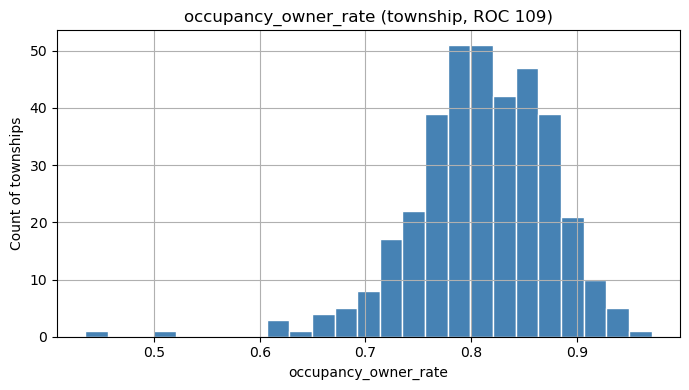


=== Owner occupancy — highest counties ===
COUNTYNAME  occupancy_owner_rate
       彰化縣                0.8689
       宜蘭縣                0.8494
       基隆市                0.8463
       新竹縣                0.8463
       雲林縣                0.8432

=== Owner occupancy — lowest counties ===
COUNTYNAME  occupancy_owner_rate
       臺中市                0.7685
       新竹市                0.7625
       新北市                0.7618
       臺北市                0.7208
       連江縣                0.6977


In [19]:
# %%
# 8. Validation and diagnostics

col = "occupancy_owner_rate"
miss = housing_features[col].isna().sum()
print("=== Missing value summary ===")
print(pd.DataFrame({
    "missing_count": [miss],
    "missing_ratio": [round(miss / len(housing_features), 4)],
}, index=[col]).to_string())

# Sanity check
valid = housing_features[col].dropna()
out_of_range = valid[(valid < 0) | (valid > 1)]
print("\n=== Sanity check (0 <= rate <= 1) ===")
if len(out_of_range):
    warnings.warn(f"{len(out_of_range)} rows out of [0,1]:\n{out_of_range}")
else:
    print("All values within [0, 1].")

# Distribution plot
fig, ax = plt.subplots(figsize=(7, 4))
valid.hist(ax=ax, bins=25, edgecolor="white", color="steelblue")
ax.set_title("occupancy_owner_rate (township, ROC 109)")
ax.set_xlabel("occupancy_owner_rate")
ax.set_ylabel("Count of townships")
plt.tight_layout()
plt.show()

# Top / bottom counties (use county panel)
county_rank = owner_county_year.sort_values(col, ascending=False)
print("\n=== Owner occupancy — highest counties ===")
print(county_rank[["COUNTYNAME", col]].head(5).round(4).to_string(index=False))
print("\n=== Owner occupancy — lowest counties ===")
print(county_rank[["COUNTYNAME", col]].tail(5).round(4).to_string(index=False))


## 9. Export processed datasets (housing + owner occupancy)


In [20]:
# %%
# 9. Export processed datasets

housing_features.to_csv(OUT_CSV, index=False, encoding='utf-8-sig')

print('Saved:', OUT_CSV)
print('Shape:', housing_features.shape)
print('\nSample rows:')
print(housing_features.head(5).to_string(index=False))
print('\nTaiwan housing feature engineering completed.')
print('Taiwan owner occupancy feature engineering completed.')


Saved: /Users/tingting/SolarPotentialMapping/data/taiwan/housing/taiwan_housing_features.csv
Shape: (368, 12)

Sample rows:
 TOWNCODE COUNTYNAME TOWNNAME  average_household_size  housing_unit_median_value  occupancy_owner_rate  housing_unit_median_value_公寓  housing_unit_median_value_別墅  housing_unit_median_value_套房  housing_unit_median_value_樓中樓  housing_unit_median_value_透天厝  housing_unit_median_value_電梯大廈
  9007010        連江縣      南竿鄉                5.946979                        NaN              0.720190                           NaN                           NaN                           NaN                            NaN                            NaN                             NaN
  9007020        連江縣      北竿鄉                6.070312                        NaN              0.700000                           NaN                           NaN                           NaN                            NaN                            NaN                             NaN
  9007030      

## 總結

- **輸出**：`data/taiwan/housing/taiwan_housing_features.csv`
- **列**：368 鄉鎮（`TOWNCODE`）
- **欄**：3 識別欄 + `average_household_size` + `housing_unit_median_value`（縣市）+ `occupancy_owner_rate` + 6 個 `housing_unit_median_value_{建物類型}`
- **交接文件**：`data/taiwan/housing/04f_taiwan_housing_summary.md`
